# Analyzing Genomic Data with Dimensionality Reduction

Diego Urdapilleta de la Parra

## Introduction

The goal of this mini-project is to demonstrate how dimensionality reduction techniques can make a daunting learning task much simpler by summarizing key information into a handful of features. In particular, we will employ Principal Component Analysis on a high-dimensional data set to capture the main sources of variability without the need of complex models or high computational cost.

The dataset that I will be using (saved under `data.txt`) originates from the 1000 Genomes Project (see [International Genome Sample Resource](https://www.internationalgenome.org/)) and contains genetic variation data from approximately 950 individuals representing seven populations of African ancestry. Each row corresponds to one individual and begins with an identifier, sex, and population code, followed by a series of columns containing single-letter entries (A, C, G, T) that represent the nucleotide bases observed at specific positions in the human genome known to vary among people (called genetic variants or single nucleotide polymorphisms, SNPs). These variant sites capture inherited differences in DNA sequences across individuals and populations, forming the basis for studying human genetic diversity and population structure.

The seven populations included in the sample are the following:

- ACB: African Caribbean in Barbados
- GWD: Gambian in Western Division, The Gambia 
- ESN: Esan in Nigeria
- MSL: Mende in Sierra Leone
- YRI: Yoruba in Ibadan, Nigeria
- LWK: Luhya in Webuye, Kenya 
- ASW: African Ancestry in Southwest US 

## Loading and Processing the Data

Since PCA requires a real-valued matrix, we begin by transforming the genetic data into numbers. The way we will go about this is by doing a binary classification of the nucleotide bases that indicates whether an individual shows a mutation at that particular SNP. In other words, for each entry $x_{ij}$, we set $x_{ij} = 0$ if the nucleobase at row $i$ and column $j$ is equal to the column's most frequent value and set $x_{ij}=1$ otherwise. This transformation will group together all mutations/deviations from the mode even if they are different (e.g., if the mode at column $j$ is "G", all instances of "A", "T", and "C" wil be turned to 1). Regardles, it will suffice for the subsequent analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.txt", sep=" ", header=None)
meta_data = df.iloc[:,:3]
genomes = df.iloc[:,3:]
modes = genomes.mode().iloc[0]
binary_mat = (~genomes.eq(modes)).astype(int).to_numpy()

In [182]:
print(f"Raw data:\n {df.iloc[0:5, 0:15]}\n")

print(f"Transformed data:\n {binary_mat[0:5, 0:10]}")

Raw data:
         0  1    2  3  4  5  6  7  8  9  10 11 12 13 14
0  HG01879  M  ACB  G  G  T  T  A  A  C  A  C  C  G  G
1  HG01880  F  ACB  A  A  T  T  A  G  C  A  T  T  G  G
2  HG01881  F  ACB  A  A  T  T  A  A  G  A  C  C  G  G
3  HG01882  M  ACB  A  A  T  C  A  A  G  A  C  C  G  G
4  HG01883  F  ACB  G  A  T  C  G  A  C  A  C  C  G  G

Transformed data:
 [[0 1 0 1 0 1 1 0 0 0]
 [1 0 0 1 0 0 1 0 1 1]
 [1 0 0 1 0 1 0 0 0 0]
 [1 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 0]]


## Brief Review of PCA

Principal Component Analysis (PCA) is a common technique used for dimensionality reduction. It transforms a dataset with possibly correlated features into a new coordinate system where the axes (called principal components) are uncorrelated and ordered by the amount of variance they capture from the original data. We can then project or "collapse" our data onto these axes, reducing the number of features we need to handle. 

In simple terms, PCA finds directions in the data that explain the most variation. The first principal component captures the highest variance, the second captures the next highest (orthogonal to the first), and so on. By keeping only the top k components, we can reduce the dimensionality of the dataset while retaining most of its information.

The following steps are taken:

1. Centering the data by subtracting the column means from each feature, so that the data is centered around zero.

2. Identifying the directions where variance is maximal (see below for more details on how this is done).

3. Transforming the original data by "collapsing" it onto the space defined by the top $k$ principal components.

Mathematically, we find the principal components via **Singular Value Decomposition (SVD)**: 

For integers $N$ and $D$, let $X\in\mathbb{R}^{N\times D}$ be a real-valued data matrix with rows $x_{i}\in\mathbb{R}^{D}$. We define the sample covariance matrix $S\in\mathbb{R}^{D\times D}$ to be
$$ S := \frac{1}{N-1}X^{\top}X = \frac{1}{N-1} \begin{bmatrix} \sum_{i=1}^{N} x_{i1}x_{i1} & \sum_{i=1}^{N} x_{i1}x_{i2} & \cdots\\
\sum_{i=1}^{N} x_{i2}x_{i1} & \sum_{i=1}^{N} x_{i2}x_{i2} & \cdots \\
\vdots & \vdots & \end{bmatrix}.$$

This matrix contains the covariances of all columns with each other. Now let $X=U\Sigma V^{\top}$ be the SVD of $X$ with singular values $\sigma_{1}, \sigma_{2}, \ldots, \sigma_{r} $, where $r = \mathrm{rank}(X)$. Then, the columns $v_{i}\in \mathbb{R}^{D}$ of $V$ are eigenvectors of $X^{\top}X$ with corresponding eigenvalues $\sigma^{2}_{i}$. Thus,
$$ X^{\top}X v_{i} = \sigma^{2}_{i}v_{i} \implies X^{\top}X V = \Sigma^{2}V^{\top}$$
$$\implies \frac{1}{N-1}X^{\top}X \begin{bmatrix} | & & |\\ v_{1} & \cdots & v_{N} \\ | & & | \end{bmatrix}  =\frac{1}{N-1} \begin{bmatrix} | & & |\\  X^{\top}X v_{1} & \cdots &  X^{\top}X v_{N} \\ | & & | \end{bmatrix} $$
$$= \frac{1}{N-1} \begin{bmatrix} | & & |\\  \sigma^{2}_{1} v_{1} & \cdots &  \sigma^{2}_{N} v_{N} \\ | & & | \end{bmatrix} $$
$$= \frac{1}{N-1} \begin{bmatrix} \sigma^{2}_{1} & 0 & \cdots \\ 0 & \sigma^{2}_{2} & \cdots \\ \vdots & \vdots & \ddots  \end{bmatrix} \begin{bmatrix} - v_{1}^{\top} - \\ \vdots \\ - v_{N}^{\top} -  \end{bmatrix}$$

$$\implies SV = \frac{1}{N-1} \Sigma^{2}V^{\top}.$$

We therefore have that the columns of $V$ are eigenvectors of the covariance matrix $S$ with corresponding eigenvalues $\sigma^{2}_{i}/(N-1)$. We call this eigenvectors *principal components*, and, for PCA, we project the rows of $X$ onto the space spanned by the first $k$ principal components. That is, for each row $x_{i}$, we have the PCA projection
$$ \pi_{\mathrm{PCA}} (x_{i}) = V_{k}V_{k}^{\top}x_{i}$$
$$ \implies \pi_{\mathrm{PCA}}(X) = \left( V_{k}V_{k}^{\top} X^{\top}\right)^{\top} =X V_{k}V_{k}^{\top} = (U\Sigma)V^{\top}_{k},$$

where $V_{k}$ is the matrix consisting of the first $k$ columns of $V$ (i.e., the PCs). Finally, we obtain the coordinate vectors of each observation in $X$ projected onto the principal component space. We call these coordinate vectors *scores* and denote them by $z_{i}$, with
$$z_{i} = V^{\top}x_{i} \implies Z:= \begin{bmatrix} | & & |\\ z_{1} & \cdots & z_{N} \\ | & & | \end{bmatrix} = \begin{bmatrix} | & & |\\ V^{top}x_{1} & \cdots & V^{\top}x_{N} \\ | & & | \end{bmatrix}$$
$$\implies Z = V^{\top}X^{\top} = XV = U\Sigma$$
$$\implies z_{i} = \sigma_{i}u_{i}.$$

This is exactly the approach that we use in the script below.

In [ ]:
def pca(X, k=None):
    n, d = X.shape

    #Remove columns with zero variance
    mask = np.var(X, axis=0) > 0
    X = X[:, mask]

    # Center
    X_mean = X.mean(axis=0)
    X_centered = X - X_mean

    #SVD
    U, Sigma, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # Output
    if k is None:
        k = min(n, d)
    components = Vt[:k, :]
    Z = U[:, :k] * Sigma[:k]
    explained_variance = (Sigma[:k] ** 2) / (n-1)
    total_variance = (Sigma ** 2).sum() / (n-1)
    explained_variance_ratio = explained_variance / total_variance

    return Z, components, X_mean, explained_variance_ratio

## Analysis

We begin by applying our PCA function to the binary matrix obtained before. We will only extract the first four principal components.

In [190]:
Z, components, X_mean, explained_variance_ratio = pca(binary_mat, 4)
pca_data = pd.DataFrame(Z)
pca_data.columns = ['PC1', 'PC2', 'PC3', 'PC4']

# Reintroduce meta data and population labels
pca_data[['id','sex','pop']] = meta_data
pop_codes = {"ACB": "African-Caribbean",
             "GWD": "Gambian",
             "ESN": "Esan",
             "MSL": "Mende",
             "YRI": "Yoruba",
             "LWK": "Luhya",
             "ASW": "African-American SW"}
pca_data['pop_full'] = [pop_codes[code] for code in pca_data['pop']]

The easiest way to know what (if anything) is being captured by the principal components is through visualizations. Specifically, we plot below histograms of the projected coordinates of the data onto each principal component. Since our analysis involves information on sex and population, we will color-code the histograms to make any relationships clearer.

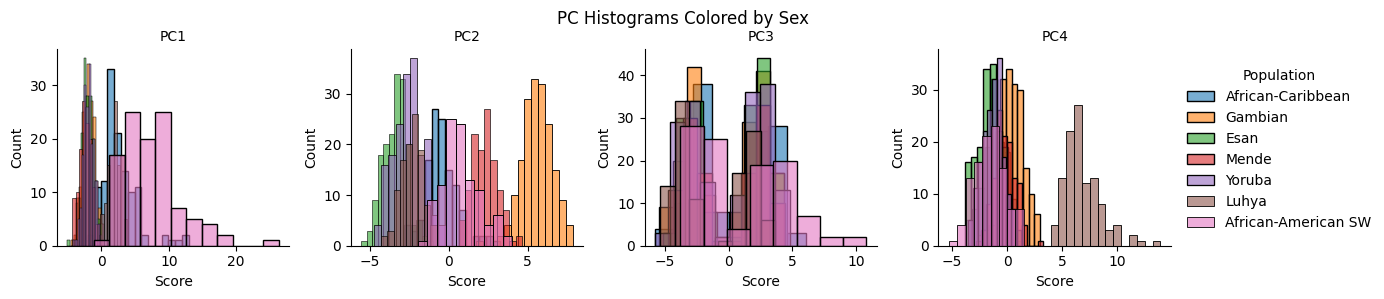

In [191]:
pca_data_melted = pca_data.melt(id_vars='pop_full', value_vars=['PC1', 'PC2', 'PC3', 'PC4'],
                                var_name='variable', value_name='Score')
g = sns.FacetGrid(pca_data_melted, col='variable', col_wrap=4, hue='pop_full', sharex=False, sharey=False)
g.map(sns.histplot, 'Score', alpha=0.6)
g.add_legend(title="Population")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.figure.suptitle("PC Histograms Colored by Sex")
plt.show()

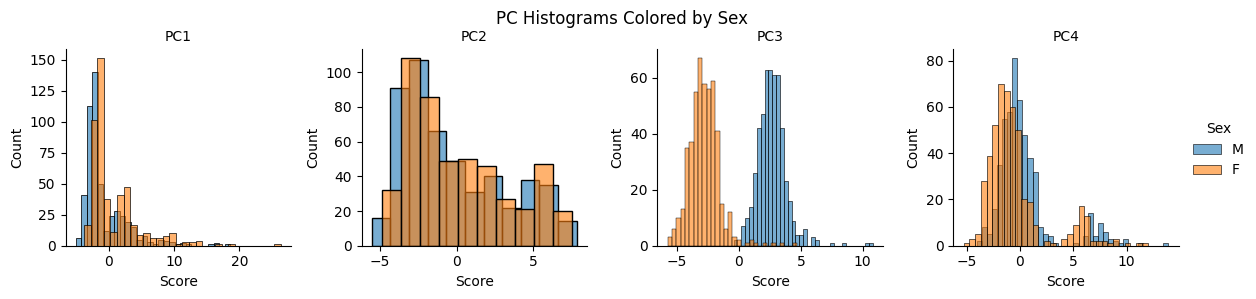

In [192]:

pca_data_melted = pca_data.melt(id_vars='sex', value_vars=['PC1', 'PC2', 'PC3', 'PC4'],
                                var_name='variable', value_name='Score')
g = sns.FacetGrid(pca_data_melted, col='variable', col_wrap=4, hue='sex', sharex=False, sharey=False)
g.map(sns.histplot, 'Score', alpha=0.6)
g.add_legend(title='Sex')
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.85)
g.figure.suptitle("PC Histograms Colored by Sex")
plt.show()


We can easily notice from these histograms that principal components 1, 2, and 4 capture some of the variability across populations. These clusters become even more apparent if we look at the scatter plots below. On the other hand, it is also clear from the histograms that the third principal component is capturing variability among sexes. 

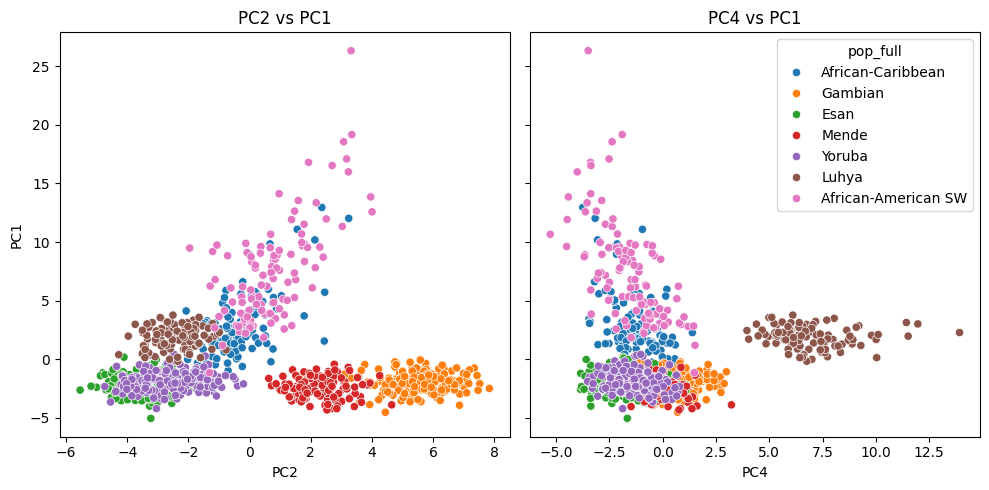

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

sns.scatterplot(data=pca_data, x='PC2', y='PC1', hue='pop_full', ax=axes[0], legend=False)
axes[0].set_title('PC2 vs PC1')

sns.scatterplot(data=pca_data, x='PC4', y='PC1', hue='pop_full', ax=axes[1])
axes[1].set_title('PC4 vs PC1')

plt.tight_layout()
plt.show()


In [188]:
import plotly.express as px

fig = px.scatter_3d(pca_data, x='PC1', y='PC2', z='PC4', 
                    color='pop_full', labels={'pop_full':'Population'}, 
                    title='Principal Components 1, 2, and 4')
fig.update_traces(marker=dict(size=2))
fig.update_layout(legend=dict(itemsizing='constant'))
fig.show()


### How much of the total variability is captured by the principal components?

In [194]:
print(explained_variance_ratio)
print(explained_variance_ratio.sum())

[0.00569445 0.00463995 0.00373793 0.00331572]
0.01738804495536289


The four first principal components only explain 1.74% of the total variance. This is not surprising: even if they give us enough information to distinguish among sex and population, the variability within sexes and populations is still huge. Indeed, even siblings only share about 50% of their DNA on average (see [this article](https://www.thetech.org/ask-a-geneticist/articles/2013/siblings-are-around-fifty-percent-related/?utm_source=chatgpt.com), for example).

## Next Steps

We have seen how dimensionality reduction can help us better understand latent relationships in complex data sets. In this last section, we demonstrate how we can use these tools to facilitate a supervised learning task. The task is to classify individuals into populations based on their genomic data, and in the script below, we adopt a simple but effective approach using MLE Logistic Regression on the first four principal components.

In [218]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

n_splits = 10
random_state = 100

X = pca_data[['PC1','PC2','PC3','PC4']].to_numpy()
y = pca_data['pop'].astype('category').cat.codes
class_names = pca_data['pop'].astype('category').cat.categories

model = LogisticRegression(penalty=None,solver='lbfgs',max_iter=1000)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

cv_results = cross_validate(model, X, y, cv=cv, scoring={'accuracy':'accuracy'})

print(f'Cross-validated accuracy: {cv_results["test_accuracy"].mean()}')


Cross-validated accuracy: 0.822111111111111
